# DecodeLabs Data Science Internship Project

## Product Sales Region Dataset Analysis

**Intern Name:** Priyanka Makwana  
**Domain:** Data Science  
**Internship:** DecodeLabs  
**Dataset:** Product-Sales-Region.xlsx

---

# TASK 1: Data Collection & Dataset Understanding

### Objective
The objective of this task is to load the dataset and understand its structure, columns, data types, and overall business context.

### Activities Performed
- Dataset Loading
- Dataset Shape Analysis
- Column Identification
- Data Type Inspection
- Dataset Information Analysis
- Categorical Value Exploration

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1.1 Import Required Libraries

The following Python libraries are imported for data analysis, visualization, and machine learning.

## Step 1.2 Load Dataset

The dataset is loaded using Pandas and basic information such as rows and columns is displayed.

In [131]:
df = pd.read_excel('Product-Sales-Region.xlsx')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1500
Columns: 19


## Step 1.3 Display First Five Records

The first five rows help us understand the structure and contents of the dataset.

In [132]:
df.head()

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,FREESHIP,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,SAVE10,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,WINTER15,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,SAVE10,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


## Step 1.4 Analyze Column Names

This step identifies all available columns in the dataset.

In [133]:
print(df.columns)

Index(['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation',
       'CustomerType', 'Discount', 'Salesperson', 'TotalPrice',
       'PaymentMethod', 'Promotion', 'Returned', 'OrderID', 'CustomerName',
       'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager'],
      dtype='object')


## Step 1.5 Check Data Types

This step helps identify whether columns contain numerical, categorical, or datetime data.

In [134]:
print(df.dtypes)

Date             datetime64[ns]
Region                   object
Product                  object
Quantity                  int64
UnitPrice               float64
StoreLocation            object
CustomerType             object
Discount                float64
Salesperson              object
TotalPrice              float64
PaymentMethod            object
Promotion                object
Returned                  int64
OrderID                  object
CustomerName             object
ShippingCost            float64
OrderDate        datetime64[ns]
DeliveryDate     datetime64[ns]
RegionManager            object
dtype: object


## Step 1.6 Dataset Information

This section provides a complete summary of the dataset including null values and memory usage.

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1130 non-null   object        
 12  Returned       1500 non-null   int64         
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

## Step 1.7 Explore Categorical Values

Unique values from important categorical columns are analyzed to understand business categories and customer behavior.

In [136]:
cat_cols = ['Region', 'Product', 'CustomerType', 'PaymentMethod', 'Promotion']

for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df[col].unique())


===== Region =====
['East' 'South' 'North' 'Central' 'West']

===== Product =====
['Laptop' 'Phone' 'Desk' 'Chair' 'Monitor' 'Tablet' 'Printer']

===== CustomerType =====
['Wholesale' 'Retail']

===== PaymentMethod =====
['Online' 'Gift Card' 'Credit Card' 'Debit Card' 'Cash']

===== Promotion =====
['FREESHIP' 'SAVE10' 'WINTER15' nan]


## Task 1 Conclusion

### Key Findings

- The dataset contains 1500 records and 19 columns.
- The dataset represents product sales transactions across multiple regions.
- Both numerical and categorical features are present.
- Important business attributes include Product, Region, Customer Type, Payment Method, and Total Price.
- The dataset is suitable for data cleaning, analysis, visualization, and predictive modeling.

### Outcome

The dataset structure has been successfully understood and is ready for further preprocessing and analysis.

# TASK 2: Data Cleaning & Preprocessing

### Objective

The objective of this task is to identify missing values, remove duplicate records, standardize data formats, and prepare the dataset for further analysis.


In [137]:
print("\n--- Missing Values Before Cleaning ---")

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_report[missing_report['Missing Count'] > 0]


--- Missing Values Before Cleaning ---


,Missing Count,Missing %
Promotion,370,24.666667


## Step 2.1 Missing Value Treatment

Missing values are identified and handled appropriately to improve data quality and reliability.


In [138]:
df['Promotion'] = df['Promotion'].fillna('No Promotion')

print("Missing values handled successfully.")
print("Remaining Missing Values:", df.isnull().sum().sum())

Missing values handled successfully.
Remaining Missing Values: 0


## Step 2.2 Duplicate Record Analysis

Duplicate records are checked to ensure data consistency and accuracy.


In [139]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")
else:
    print("No duplicate records found.")

Duplicate Rows: 0
No duplicate records found.


## Step 2.3 Date Formatting and Feature Engineering

Date columns are converted into datetime format and new time-based features are created for analysis.


In [140]:
df['Date'] = pd.to_datetime(df['Date'])
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])

In [141]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter

df['DeliveryDays'] = (
    df['DeliveryDate'] - df['OrderDate']
).dt.days

df[['Year','Month','MonthName','Quarter','DeliveryDays']].head()

,Year,Month,MonthName,Quarter,DeliveryDays
0,2023,2,Feb,1,4
1,2024,12,Dec,4,9
2,2023,5,May,2,9
3,2025,2,Feb,1,4
4,2023,6,Jun,2,3


## Step 2.4 Data Validation

Numeric columns are checked for invalid or negative values to ensure data integrity.


In [142]:
for col in ['Quantity', 'UnitPrice', 'TotalPrice', 'ShippingCost']:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")

Quantity: 0 negative values
UnitPrice: 0 negative values
TotalPrice: 0 negative values
ShippingCost: 0 negative values


## Step 2.5 Final Clean Dataset Verification

The cleaned dataset is verified to confirm that missing values have been handled and new features have been created successfully.


In [143]:
print("Dataset Shape:", df.shape)
print("Remaining Missing Values:", df.isnull().sum().sum())

df.head()

Dataset Shape: (1500, 24)
Remaining Missing Values: 0


,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,...,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager,Year,Month,MonthName,Quarter,DeliveryDays
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,...,Cust 6583,43.34,2023-02-23,2023-02-27,Eric,2023,2,Feb,1,4
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,...,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie,2024,12,Dec,4,9
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,...,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan,2023,5,May,2,9
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,...,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron,2025,2,Feb,1,4
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,...,Cust 6506,5.73,2023-06-24,2023-06-27,Eric,2023,6,Jun,2,3


## Task 2 Conclusion

### Key Findings

* Missing values were identified and handled successfully.
* No duplicate records were found in the dataset.
* Date columns were converted into datetime format.
* New features such as Year, Month, Quarter, and DeliveryDays were created.
* The dataset is now clean and ready for exploratory data analysis.

### Outcome

Task 2 has been completed successfully and the dataset is prepared for further analysis and visualization.


# TASK 3: Exploratory Data Analysis (EDA)

### Objective

The objective of this task is to analyze the dataset, identify trends, discover patterns, detect outliers, and generate meaningful business insights.

## Step 3.1 Basic Statistical Analysis

Descriptive statistics are calculated to understand the distribution, central tendency, and variability of numerical features.

In [144]:
print("Basic Statistical Summary")

df[['Quantity', 'UnitPrice', 'Discount',
    'TotalPrice', 'ShippingCost',
    'DeliveryDays']].describe().round(2)

Basic Statistical Summary


,Quantity,UnitPrice,Discount,TotalPrice,ShippingCost,DeliveryDays
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,10.41,298.83,0.07,2919.99,27.51,6.04
std,5.74,169.10,0.06,2522.79,13.09,2.54
min,1.00,5.52,0.00,6.97,5.01,2.00
25%,5.00,151.02,0.00,867.14,16.70,4.00
50%,11.00,294.74,0.05,2174.72,27.10,6.00
75%,15.00,446.70,0.10,4414.72,38.64,8.00
max,20.00,599.72,0.15,11077.00,49.98,10.00


## Step 3.2 Sales Revenue Analysis by Region

This analysis helps identify which region contributes the highest revenue.

In [145]:
region_sales = df.groupby('Region')['TotalPrice'].sum().sort_values(ascending=False)

print("Total Sales Revenue by Region")
print(region_sales.round(2))

Total Sales Revenue by Region
Region
North      967957.98
East       883633.72
West       853478.86
Central    847153.68
South      827768.19
Name: TotalPrice, dtype: float64


## Step 3.3 Product Performance Analysis

This analysis identifies the products generating the highest revenue.

In [146]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

print("Total Sales Revenue by Product")
print(product_sales.round(2))

Total Sales Revenue by Product
Product
Tablet     684539.39
Laptop     684417.24
Printer    684387.42
Monitor    651629.39
Chair      622589.48
Desk       555266.66
Phone      497162.85
Name: TotalPrice, dtype: float64


## Step 3.4 Monthly Sales Trend Analysis

Monthly sales trends are analyzed to identify seasonal patterns and revenue fluctuations.

In [147]:
monthly_sales = df.groupby(
    ['Year', 'Month']
)['TotalPrice'].sum().reset_index()

monthly_sales = monthly_sales.sort_values(
    ['Year', 'Month']
)

monthly_sales.tail(12)

,Year,Month,TotalPrice
18,2024,7,140155.7075
19,2024,8,129927.5060
20,2024,9,130502.6035
21,2024,10,178167.1965
22,2024,11,138174.2850
23,2024,12,143039.6205
24,2025,1,171098.0930
25,2025,2,138184.6330
26,2025,3,183193.7690
27,2025,4,128675.0145


## Step 3.5 Return Rate Analysis

Return rates are analyzed to identify products with higher customer return behavior.

In [148]:
return_rate = df.groupby(
    'Product'
)['Returned'].mean() * 100

print(return_rate.round(2).sort_values(
    ascending=False
))

Product
Chair      28.23
Laptop     27.43
Monitor    26.42
Tablet     24.17
Phone      23.08
Printer    22.27
Desk       21.74
Name: Returned, dtype: float64


## Step 3.6 Customer Type Analysis

Revenue contribution from Retail and Wholesale customers is analyzed.

In [149]:
df.groupby(
    'CustomerType'
)['TotalPrice'].agg(
    ['sum', 'mean', 'count']
).round(2)

,sum,mean,count
CustomerType,,,
Retail,2195525.59,2950.98,744
Wholesale,2184466.84,2889.51,756


## Step 3.7 Top Salesperson Analysis

The highest-performing salespersons are identified based on revenue generation.

In [150]:
top_sales = df.groupby(
    'Salesperson'
)['TotalPrice'].sum().sort_values(
    ascending=False
).head(5)

print(top_sales.round(2))

Salesperson
Bob       796780.52
Alice     786165.84
Frank     714641.52
Carlos    707166.72
Eva       698669.58
Name: TotalPrice, dtype: float64


## Step 3.8 Correlation Analysis

Correlation analysis helps understand relationships between numerical variables.

In [151]:
corr = df[['Quantity',
           'UnitPrice',
           'Discount',
           'TotalPrice',
           'ShippingCost',
           'DeliveryDays']].corr()

corr.round(2)

,Quantity,UnitPrice,Discount,TotalPrice,ShippingCost,DeliveryDays
Quantity,1.00,0.04,0.02,0.67,-0.02,-0.01
UnitPrice,0.04,1.00,0.01,0.68,0.00,-0.01
Discount,0.02,0.01,1.00,-0.06,-0.03,-0.01
TotalPrice,0.67,0.68,-0.06,1.00,-0.01,-0.02
ShippingCost,-0.02,0.00,-0.03,-0.01,1.00,-0.03
DeliveryDays,-0.01,-0.01,-0.01,-0.02,-0.03,1.00


## Step 3.9 Outlier Detection

The Interquartile Range (IQR) method is used to identify unusual sales transactions.

In [152]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

outliers = df[
    (df['TotalPrice'] < lower) |
    (df['TotalPrice'] > upper)
]

print("Q1 =", round(Q1, 2))
print("Q3 =", round(Q3, 2))
print("IQR =", round(IQR, 2))
print("Lower Bound =", round(lower, 2))
print("Upper Bound =", round(upper, 2))
print("Number of Outliers =", len(outliers))

Q1 = 867.14
Q3 = 4414.72
IQR = 3547.59
Lower Bound = -4454.24
Upper Bound = 9736.1
Number of Outliers = 17


## Task 3 Conclusion

### Key Findings

- Revenue distribution was analyzed across regions and products.
- Monthly sales trends were identified.
- Customer return behavior was examined.
- Retail and Wholesale customer contributions were compared.
- Correlation analysis revealed relationships between important variables.
- High-value outlier transactions were detected successfully.

### Outcome

The exploratory data analysis phase has been completed successfully. The dataset insights obtained in this task will support effective visualization and predictive modeling in the next stages.

# TASK 4: Data Visualization

### Objective

The objective of this task is to create meaningful visualizations that help understand sales performance, customer behavior, product trends, and business insights.

## Chart 1: Total Sales Revenue by Region

This chart compares total revenue generated across different regions.

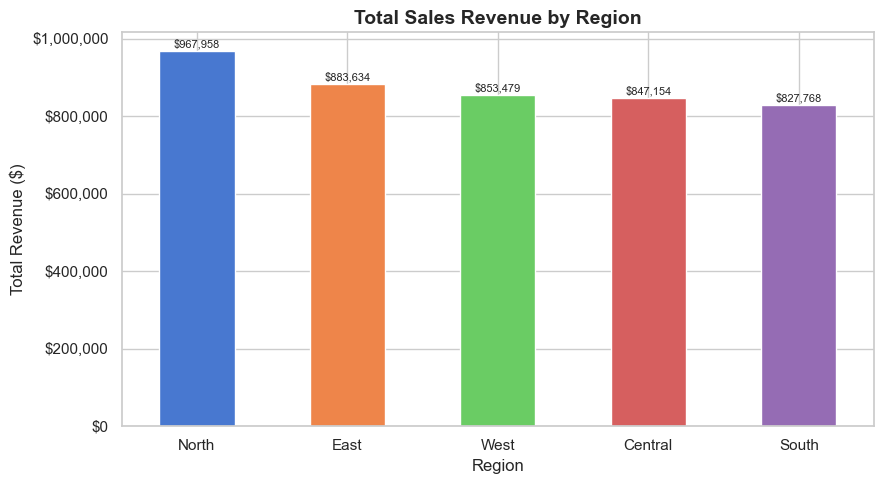

In [153]:
fig, ax = plt.subplots(figsize=(9, 5))

region_sales.plot(
    kind='bar',
    ax=ax,
    color=sns.color_palette("muted", len(region_sales)),
    edgecolor='white'
)

ax.set_title(
    'Total Sales Revenue by Region',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Revenue ($)', fontsize=12)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'${x:,.0f}'
    )
)

ax.tick_params(axis='x', rotation=0)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10000,
        f'${bar.get_height():,.0f}',
        ha='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

## Chart 2: Total Sales Revenue by Product

This chart shows which products generate the highest revenue.

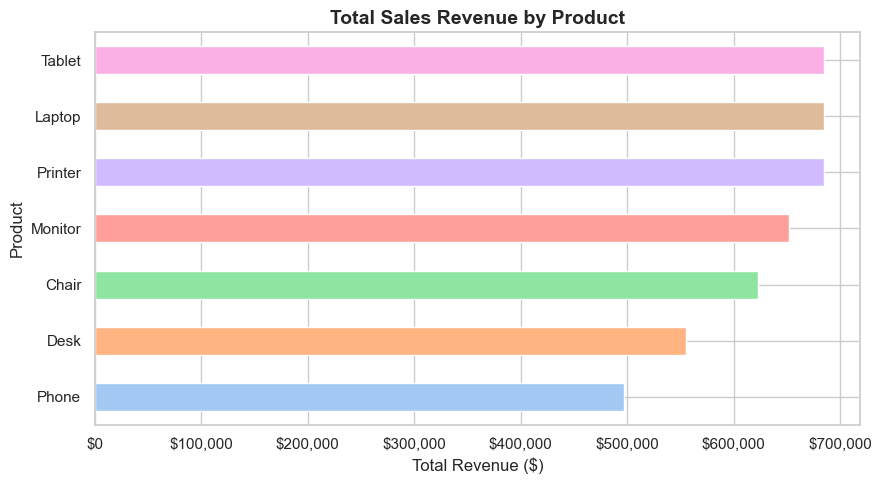

In [154]:
fig, ax = plt.subplots(figsize=(9, 5))

product_sales.sort_values().plot(
    kind='barh',
    ax=ax,
    color=sns.color_palette("pastel", len(product_sales))
)

ax.set_title(
    'Total Sales Revenue by Product',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Total Revenue ($)')
ax.set_ylabel('Product')

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'${x:,.0f}'
    )
)

plt.tight_layout()
plt.show()

## Chart 3: Monthly Sales Trend

This line chart displays monthly sales trends over time.

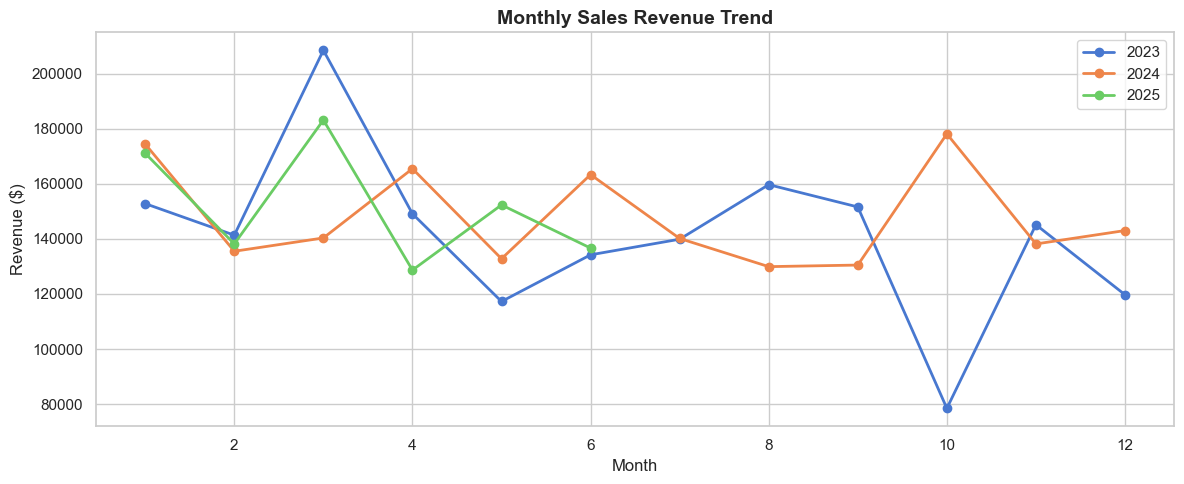

In [155]:
fig, ax = plt.subplots(figsize=(12, 5))

for year in monthly_sales['Year'].unique():

    subset = monthly_sales[
        monthly_sales['Year'] == year
    ]

    ax.plot(
        subset['Month'],
        subset['TotalPrice'],
        marker='o',
        label=str(year),
        linewidth=2
    )

ax.set_title(
    'Monthly Sales Revenue Trend',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')

ax.legend()

plt.tight_layout()
plt.show()

## Chart 4: Product Distribution

This pie chart shows product order distribution.

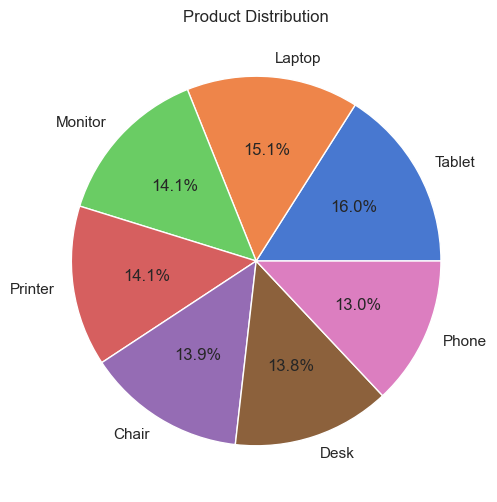

In [156]:
product_count = df['Product'].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    product_count,
    labels=product_count.index,
    autopct='%1.1f%%'
)

plt.title('Product Distribution')

plt.show()

## Chart 5: Payment Method Distribution

This chart displays customer payment preferences.

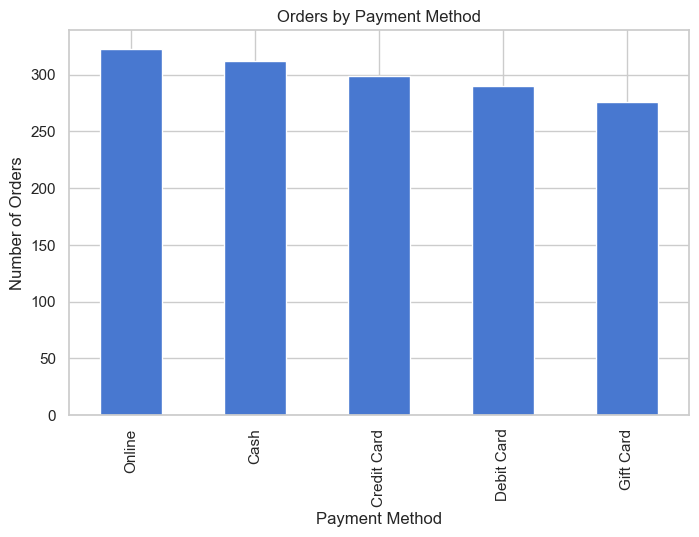

In [157]:
payment_counts = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8,5))

payment_counts.plot(
    kind='bar'
)

plt.title('Orders by Payment Method')

plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')

plt.show()

## Chart 6: Correlation Heatmap

This heatmap visualizes relationships among numerical variables.

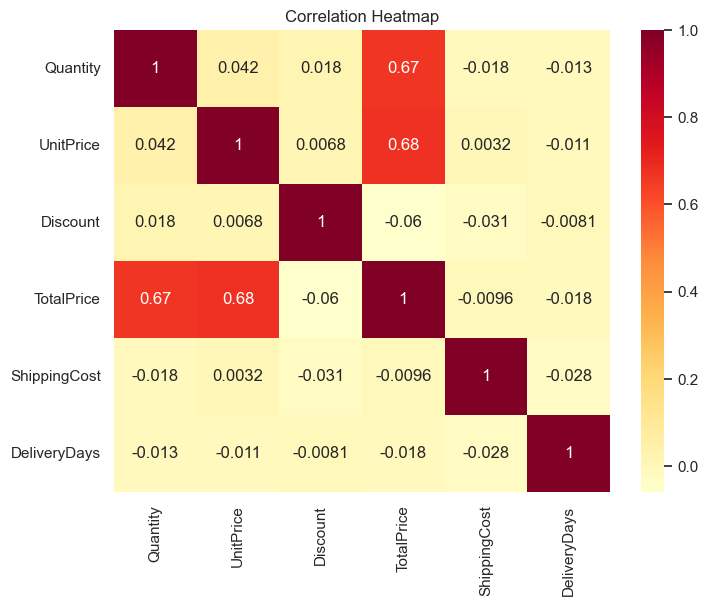

In [158]:
num_cols = [
    'Quantity',
    'UnitPrice',
    'Discount',
    'TotalPrice',
    'ShippingCost',
    'DeliveryDays'
]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlOrRd'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

## Chart 7: Total Price Distribution by Region

This boxplot helps identify spread and outliers.

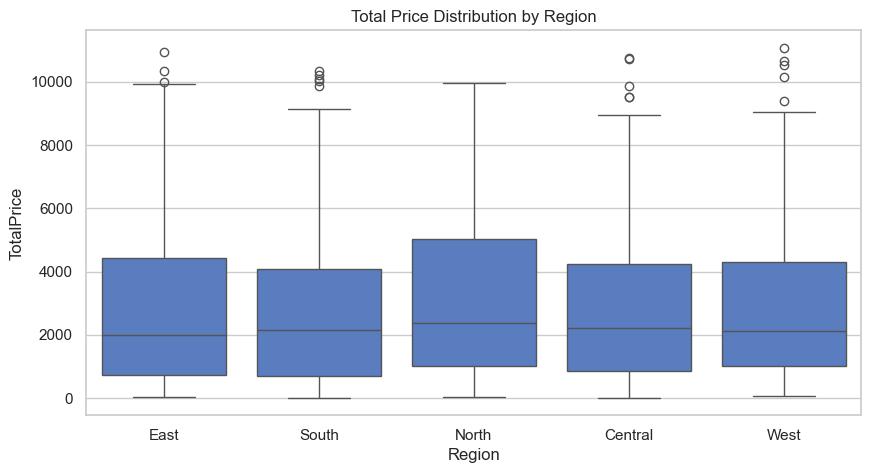

In [159]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Region',
    y='TotalPrice'
)

plt.title(
    'Total Price Distribution by Region'
)

plt.show()

## Chart 8: Return Rate by Product

This chart shows product return percentages.

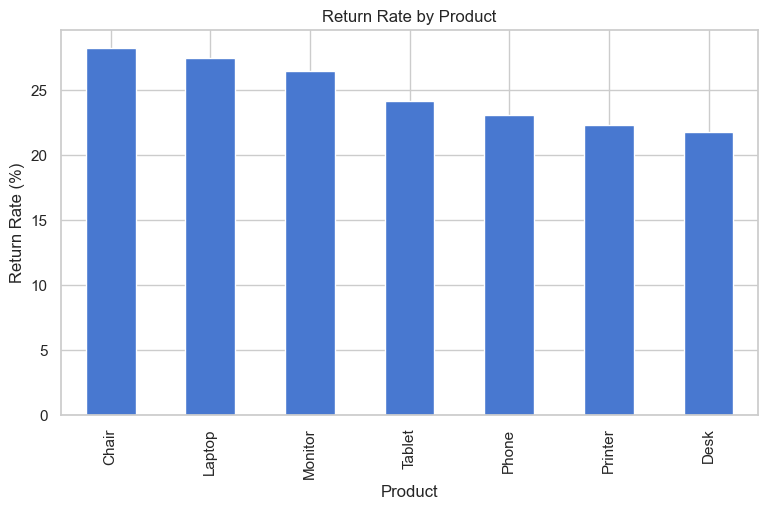

In [160]:
return_rate.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(9,5)
)

plt.title(
    'Return Rate by Product'
)

plt.xlabel('Product')
plt.ylabel('Return Rate (%)')

plt.show()

## Chart 9: Customer Type Revenue Comparison

This chart compares revenue generated by Retail and Wholesale customers.

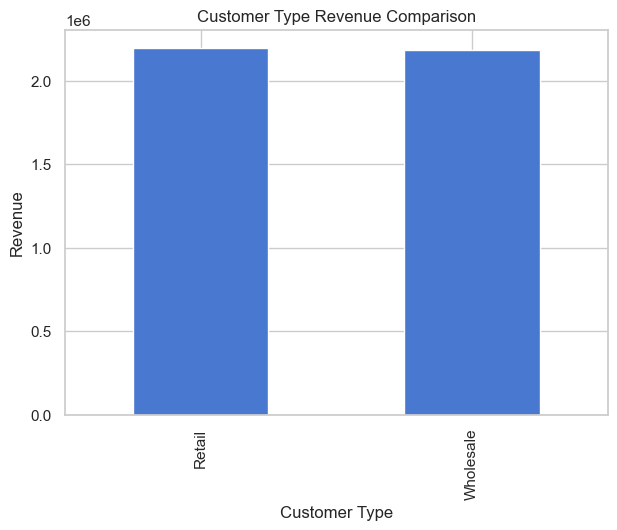

In [161]:
ct_rev = df.groupby(
    'CustomerType'
)['TotalPrice'].sum()

ct_rev.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title(
    'Customer Type Revenue Comparison'
)

plt.xlabel('Customer Type')
plt.ylabel('Revenue')

plt.show()

## Task 4 Conclusion

### Key Findings

- Sales performance was visualized across regions and products.
- Monthly sales trends were identified.
- Customer payment behavior was analyzed.
- Correlation between variables was visualized.
- Product return rates were compared.
- Revenue contribution by customer type was analyzed.

### Outcome

Task 4 has been completed successfully. Visualizations provided meaningful business insights and improved understanding of the dataset.

# TASK 5: Predictive Model - Linear Regression

### Objective

The objective of this task is to build a machine learning model that predicts Total Sales Price using important sales-related features. Linear Regression is used as the predictive algorithm.

## Step 5.1 Feature Selection and Data Preparation

Relevant features are selected and categorical variables are converted into numerical format for machine learning.

In [162]:
model_df = df[
    [
        'Quantity',
        'UnitPrice',
        'Discount',
        'ShippingCost',
        'Region',
        'TotalPrice'
    ]
].copy()

le = LabelEncoder()

model_df['Region_Encoded'] = le.fit_transform(
    model_df['Region']
)

print("Categorical encoding completed")

print(
    dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )
)

Categorical encoding completed
{'Central': np.int64(0), 'East': np.int64(1), 'North': np.int64(2), 'South': np.int64(3), 'West': np.int64(4)}


## Step 5.2 Define Features and Target Variable

The independent variables (X) and target variable (y) are prepared.

In [163]:
X = model_df[
    [
        'Quantity',
        'UnitPrice',
        'Discount',
        'ShippingCost',
        'Region_Encoded'
    ]
]

y = model_df['TotalPrice']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1500, 5)
Target Shape: (1500,)


## Step 5.3 Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

Training Records: 1200
Testing Records: 300


## Step 5.4 Model Training

A Linear Regression model is trained using the training dataset.

In [165]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model trained successfully")

Model trained successfully


## Step 5.5 Prediction

The trained model is used to predict TotalPrice values.

In [166]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


## Step 5.6 Model Evaluation

The model is evaluated using MAE, MSE, RMSE and R² Score.

In [167]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 712.852032157063
MSE : 876844.9628536558
RMSE : 936.4000015237376
R2 Score : 0.8736152229444303


## Step 5.7 Actual vs Predicted Comparison

The actual and predicted values are compared to evaluate prediction quality.

In [168]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10].round(2)
})

comparison

,Actual Price,Predicted Price
0,4956.588,4735.48
1,2311.540,2375.94
2,8514.470,7012.97
3,9095.870,7294.75
4,1529.286,3494.39
5,1838.050,2287.67
6,3784.788,3827.52
7,8878.947,7262.22
8,6834.408,6320.71
9,299.047,-674.80


## Step 5.8 Actual vs Predicted Visualization

A scatter plot is created to compare actual and predicted values.

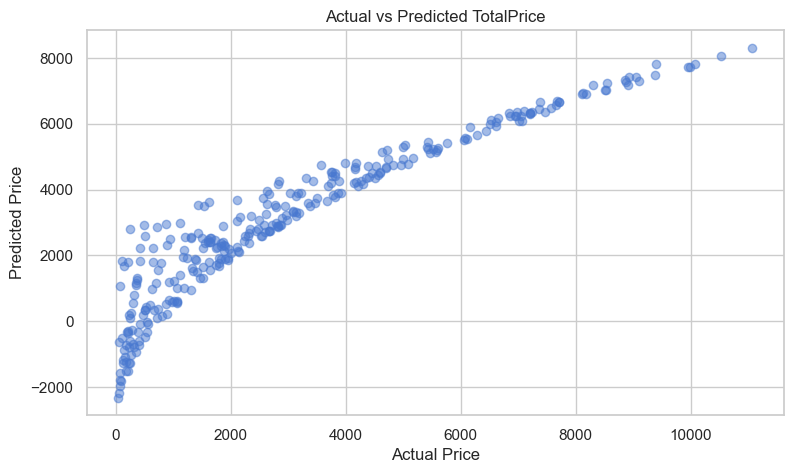

In [169]:
plt.figure(figsize=(9,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.title(
    'Actual vs Predicted TotalPrice'
)

plt.xlabel(
    'Actual Price'
)

plt.ylabel(
    'Predicted Price'
)

plt.show()

## Step 5.9 Feature Importance Analysis

Model coefficients are analyzed to understand feature impact.

In [170]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df

,Feature,Coefficient
0,Quantity,280.588479
1,UnitPrice,9.614428
2,Discount,-3264.352660
3,ShippingCost,-0.227202
4,Region_Encoded,8.300073


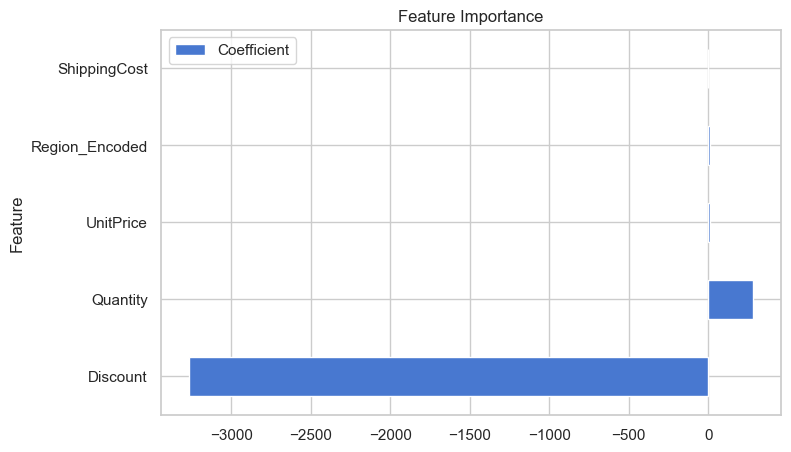

In [171]:
coef_df.sort_values(
    'Coefficient',
    key=abs,
    ascending=False
).plot(
    kind='barh',
    x='Feature',
    y='Coefficient',
    figsize=(8,5)
)

plt.title(
    'Feature Importance'
)

plt.show()

## Step 5.10 Business Insights

Important findings generated from the analysis and predictive model.

In [172]:
print(
    "Top Region :",
    region_sales.idxmax()
)

print(
    "Top Product :",
    product_sales.idxmax()
)

print(
    "Lowest Return Product :",
    return_rate.idxmin()
)

print(
    "Average Delivery Days :",
    round(
        df['DeliveryDays'].mean(),
        2
    )
)

print(
    "Model Accuracy :",
    round(
        r2*100,
        2
    ),
    "%"
)

Top Region : North
Top Product : Tablet
Lowest Return Product : Desk
Average Delivery Days : 6.04
Model Accuracy : 87.36 %


# Project Conclusion

### Key Achievements

- Successfully completed Data Collection and Dataset Understanding.
- Performed Data Cleaning and Preprocessing.
- Conducted Exploratory Data Analysis (EDA).
- Created meaningful visualizations.
- Built a Linear Regression Machine Learning Model.
- Generated business insights from sales data.

### Final Outcome

All five internship tasks have been completed successfully. The project demonstrates practical knowledge of Data Science, Data Analysis, Data Visualization, and Machine Learning using Python.